# Example on overfitting

Suppose we want to predict next month returns of the S\&P500 index
- Sample: 2021:M1 -- 2025:M12
- Explanatory variable: $r_{t-1}$
- Train sample: until 2025:M6
- Test sample: last 6 months of 2025
We fit:

$$
r_{t} = f(r_{t-1}) + \epsilon_t
$$

We use different models:

- Linear model: Ordinary Least Squares (OLS) 
- Non linear model: splines (with different degrees)

## 0. Required packages and helper function

We import the required libraries and define a function to compute the Mean Squared Error (MSE) as:
$$
\text{MSE} = \frac{1}{n} \sum_{i=1}^n (y_i - \hat{f}(x_i))^2
$$

In [3]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
from patsy import dmatrix, build_design_matrices

def mse(y, yhat):
    y = np.asarray(y)
    yhat = np.asarray(yhat)
    return np.mean((y - yhat) ** 2)

## 1. Retrieve data

We can use the `yfinance` Python package, which takes the following arguments:

- ticker
- start/end

where the S&P500 ticker is `^GSPC`

In [4]:
ticker = "^GSPC"
start, end = "2021-01-01", "2025-12-31"

raw = yf.download(ticker, start=start, end=end, interval="1mo", progress=False, auto_adjust=True)
px = raw["Adj Close"] if "Adj Close" in raw.columns else raw["Close"]
df = px.pct_change().dropna() * 100.0  # percent returns
df.columns = ["y"]
df["x"] = df["y"].shift(1)  # lag-1 return as regressor
df = df.dropna()

## 2. Train and test sample

We use data from 2021:M1 -- 2025:M12 as train sample (data on which we fit the model) and from 2026:M1 -- 2026:M6 as test sample (data on which we test models' predictions)

In [5]:
split = int(0.9 * len(df))
train = df.iloc[:split].copy()
test  = df.iloc[split:].copy()

## 3. OLS

The OLS is fit using `statsmodels`. Recall, the package does not automatically include the constant. This is done by `sm.add_constant()`

In [6]:
X_tr = sm.add_constant(train["x"])
X_te = sm.add_constant(test["x"])
lin = sm.OLS(train["y"], X_tr).fit()
lin_tr_mse = mse(train["y"], lin.predict(X_tr))
lin_te_mse = mse(test["y"], lin.predict(X_te))

train_mse = [lin_tr_mse]
test_mse = [lin_te_mse]

## 4. Splines

Next we fit a non linear model with degrees from 4 to 30. The larger the degree, the more flexible the model

In [7]:
def fit_spline(train, test, df_spline, lb, ub):
    # df_spline should be >= 4 for cubic splines to behave nicely
    formula = (
        f"bs(x, df={df_spline}, degree=3, include_intercept=False, "
        f"lower_bound=lb, upper_bound=ub)"
    )

    B_tr = dmatrix(formula, {"x": train["x"], "lb": lb, "ub": ub}, return_type="dataframe")
    info = B_tr.design_info
    B_te = build_design_matrices([info], {"x": test["x"], "lb": lb, "ub": ub})[0]

    model = sm.OLS(train["y"], B_tr).fit()
    return model, info, mse(train["y"], model.predict(B_tr)), mse(test["y"], model.predict(B_te))

models = {}  # store a few fits for plotting curves

lb = float(df["x"].min())
ub = float(df["x"].max())

df_list = list(range(4, 31))
for d in df_list:
    m, info, tr, te = fit_spline(train, test, d, lb, ub)
    train_mse.append(tr)
    test_mse.append(te)
    models[d] = (m, info)

## 5. Plot

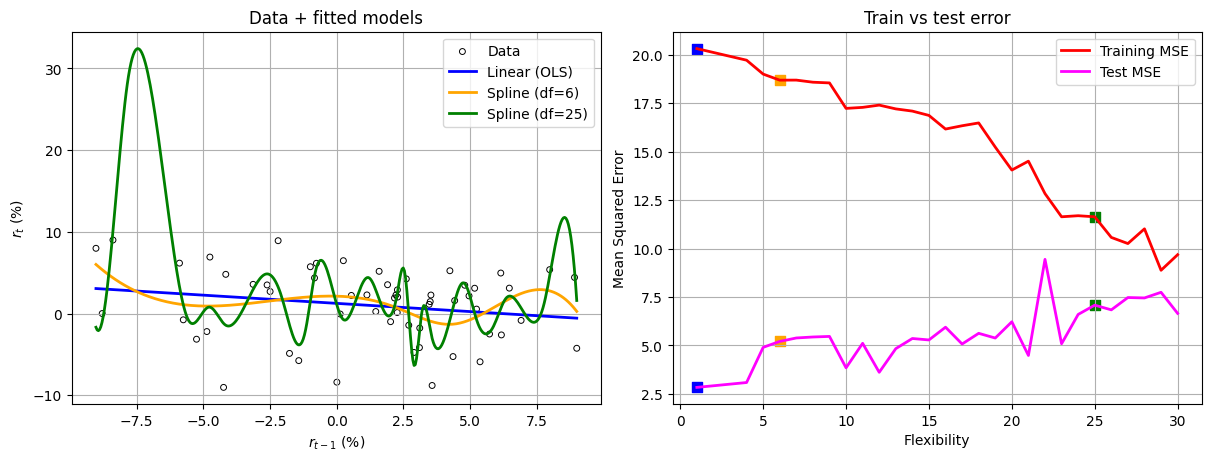

In [8]:

flex = [1] + df_list  # treat "1" as the least flexible (linear) baseline

# Choose two spline df values to show on the left panel (moderate + very flexible)
df_mid = 6
df_high = 25

if df_mid not in models or df_high not in models:
    df_mid = df_list[len(df_list) // 5]
    df_high = df_list[-1]

# Grid for smooth fitted curves
x_grid = np.linspace(df["x"].quantile(0.01), df["x"].quantile(0.99), 400)
grid = pd.DataFrame({"x": x_grid})

# Predictions on grid
lin_grid = lin.predict(sm.add_constant(x_grid))

m_mid, info_mid = models[df_mid]
B_grid_mid = build_design_matrices([info_mid], grid)[0]
mid_grid = m_mid.predict(B_grid_mid)

m_hi, info_hi = models[df_high]
B_grid_hi = build_design_matrices([info_hi], grid)[0]
hi_grid = m_hi.predict(B_grid_hi)

# For readability, clip extremes in the scatter ONLY (MSE uses raw data)
x_plot = df["x"].clip(df["x"].quantile(0.01), df["x"].quantile(0.99))
y_plot = df["y"].clip(df["y"].quantile(0.01), df["y"].quantile(0.99))

# ----------------------------
# 4) Plot: ISLR-style two panels
# ----------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

colors = ['blue', 'orange', 'green']
# Left panel: scatter + 3 fits
ax[0].scatter(x_plot, y_plot, s=18, facecolors="none", edgecolors="black", linewidths=0.7, label=f"Data")
ax[0].plot(x_grid, lin_grid, linewidth=2, label="Linear (OLS)", color=colors[0])
ax[0].plot(x_grid, mid_grid, linewidth=2, label=f"Spline (df={df_mid})", color=colors[1])
ax[0].plot(x_grid, hi_grid, linewidth=2, label=f"Spline (df={df_high})", color=colors[2])
ax[0].set_xlabel(r"$r_{t-1}$ (%)")
ax[0].set_ylabel(r"$r_t$ (%)")
ax[0].set_title("Data + fitted models")
ax[0].legend(frameon=True)
ax[0].grid(True)


# Right panel: training/test MSE vs flexibility
ax[1].plot(flex, train_mse, linewidth=2, label="Training MSE", color='red')
ax[1].plot(flex, test_mse, linewidth=2, label="Test MSE", color='magenta')
#ax[1].axhline(min(test_mse), linestyle="--", linewidth=1, label="Best test MSE (among tried models)")


# Mark the three fits shown on the left with squares
def mark_point(f, tr, te, color):
    ax[1].scatter([f], [tr], marker="s", s=60, color=color)
    ax[1].scatter([f], [te], marker="s", s=60, color=color)


# linear point at flexibility=1
mark_point(1, lin_tr_mse, lin_te_mse, color=colors[0])


# spline points at their df
# find their MSE values from lists (offset because train_mse/test_mse include linear first)
def mse_at_df(d):
    j = df_list.index(d) + 1
    return train_mse[j], test_mse[j]


tr_mid, te_mid = mse_at_df(df_mid)
tr_hi, te_hi = mse_at_df(df_high)
mark_point(df_mid, tr_mid, te_mid, color=colors[1])
mark_point(df_high, tr_hi, te_hi, color=colors[2])

ax[1].set_xlabel("Flexibility")
ax[1].set_ylabel("Mean Squared Error")
ax[1].set_title("Train vs test error")
ax[1].legend(frameon=True)
ax[1].grid(True)

plt.savefig("Overfitting.png", dpi=300, bbox_inches='tight')

